### SubAgents

A deep agents can create subagents to delegate work. You can specify custom subagents in the subagents parameter. Subagents are useful for context quarantine(keeping the main agent's context clean) and for providing specialized instructions. This page covers synchronous subagents, where the supervisor, where the supervisor blocks until the subagents finishes. For long-runnig tasks, parallel workstreams or cases where you need mid-flight steering and cancellation, see Async subagents.

In [6]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["MISTRAL_API_KEY"]=os.getenv("MISTRAL_API_KEY")
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")


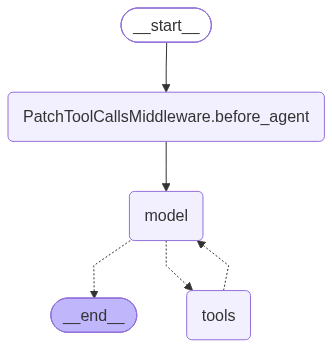

In [17]:
import os
from typing import Literal

from deepagents import create_deep_agent
from tavily import TavilyClient

tavily_client = TavilyClient(api_key=os.environ["TAVILY_API_KEY"])

def internet_search(
    query: str,
    max_results: int = 5,
    topic: Literal["general", "news", "finance"] = "general",
    include_raw_content: bool = False,
):
 """Run a web search"""
 return tavily_client.search(
        query,
        max_results=max_results,
        include_raw_content=include_raw_content,
        topic=topic,
    )


research_subagent={
    "name": "research-agent",
    "description": "Used to research more in depth questions",
    "system_prompt": "You are a great researcher",
    "tools": [internet_search],
    "model": "groq:qwen/qwen3.6-27b",  

}
subagents=[research_subagent]

agent=create_deep_agent(
    model="groq:openai/gpt-oss-120b",
    subagents=subagents
)
agent

In [8]:
result = agent.invoke(
    {
        "messages":[{
            "role": "user",
            "content": "Research about LLM Gateways and provide me a detailed summary.",
        }],
    },
    config = {"configurable": {"thread_id": "skills-demo-2"}},
)

for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research about LLM Gateways and provide me a detailed summary.
================================== Ai Message ==================================
Tool Calls:
  glob (fc_122e0952-8e48-4af2-ace0-a98fbbc3cc25)
 Call ID: fc_122e0952-8e48-4af2-ace0-a98fbbc3cc25
  Args:
    path: 
    pattern: *gateway*
================================= Tool Message =================================
Name: glob

No files found
================================== Ai Message ==================================

**LLM Gateways – A Detailed Overview**

---

## 1. What Is an LLM Gateway?

An **LLM (Large Language Model) Gateway** is a software layer that sits between client applications and one or more LLM providers (e.g., OpenAI, Anthropic, Google Gemini, Meta LLaMA, Cohere, etc.). Its primary role is to **standardize, orchestrate, and enrich** the interaction with LLMs, turning raw model APIs into a more developer‑friendly, secure, and

### Structured Output with Sub Agents

In [20]:
from pydantic import BaseModel, Field
from deepagents import create_deep_agent

class ResearchFindings(BaseModel):
    """Structured findings from a research task."""
    summary: str = Field(description="Summary of findings")
    confidence: float = Field(description="Confidence score from 0 to 1")
    sources: list[str] = Field(description="List of source URLs")

research_subagent = {
    "name": "researcher",
    "description": "Researches topics and returns structured findings",
    "system_prompt": "Research the given topic thoroughly. Return your findings.",
    "tools": [internet_search],
    "response_format": ResearchFindings,
}

agent = create_deep_agent(
    model="groq:openai/gpt-oss-20b",
    subagents=[research_subagent],
)

result = await agent.ainvoke(
    {"messages": [{"role": "user", "content": "Research recent advances in quantum computing"}]}
)

In [21]:
for m in result["messages"]:
    m.pretty_print()

================================ Human Message =================================

Research recent advances in quantum computing
================================== Ai Message ==================================
Tool Calls:
  ls (fc_17067e14-7789-4fb0-902c-ac92aaa81c55)
 Call ID: fc_17067e14-7789-4fb0-902c-ac92aaa81c55
  Args:
    path: /
================================= Tool Message =================================
Name: ls

No files found
================================== Ai Message ==================================

## Recent Advances in Quantum Computing (2023‑2024)

| Category | Key Milestone | What it Means | Source |
|----------|---------------|---------------|--------|
| **Hardware & Architecture** | **IBM Quantum H2‑1 (QVM‑12)** – 127‑qubit processor with 3‑D superconducting qubits, 100 ns gate times, 99.9 % fidelity | Pushes toward fault‑tolerant thresholds; first 100‑+ qubit device with full connectivity. | IBM Q System‑X, *Nature* 2024 |
| | **Google Sycamore‑V2** – 54‑qub